<a href="https://colab.research.google.com/github/sahitchallakonda18/Sahit/blob/main/Nexgen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

       GEIOD APPROXIMATION FROM SATELLITE DATA (E5)

PROJECT CONFIGURATION
-----------------------------------------------------------------
Latitude points : 20
Longitude points: 36
SVD Rank        : 4
Missing rate    : 30.0 %
Iterations      : 30

GRID
-----------------------------------------------------------------
Matrix shape: (20, 36)

BENCHMARK DATA
-----------------------------------------------------------------
Minimum: -1.4265
Maximum: 1.4404
Mean   : -0.0003


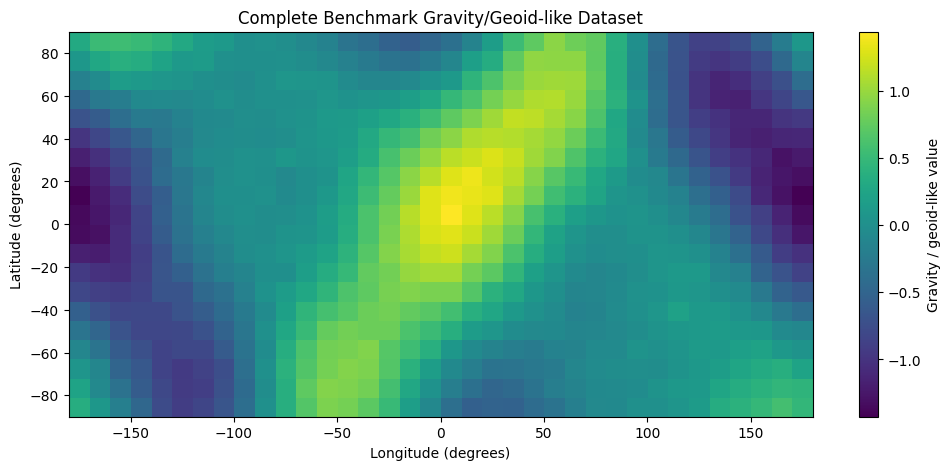


SPARSE DATA
-----------------------------------------------------------------
Observed measurements: 501
Missing measurements : 219
Observed percentage   : 69.58 %
Missing percentage    : 30.42 %


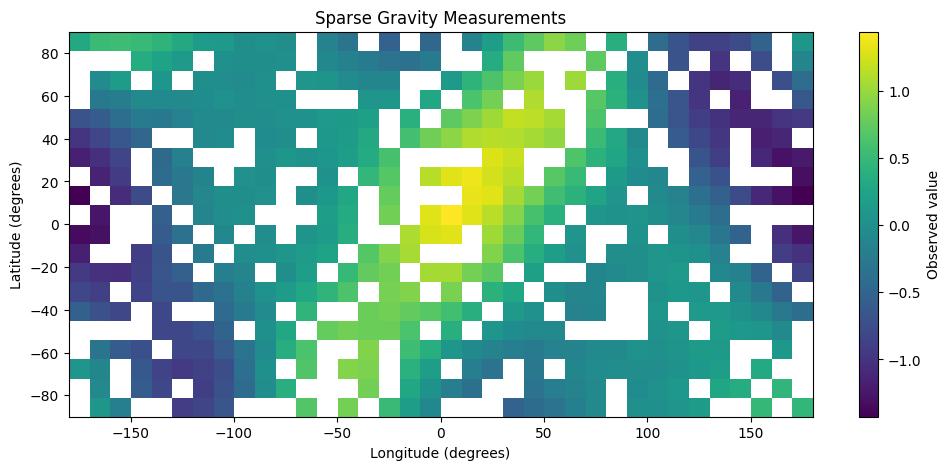


SVD RESULTS
-----------------------------------------------------------------
Original matrix shape: (20, 36)
U shape              : (20, 20)
Sigma shape          : (20,)
Vᵀ shape             : (20, 36)

First 10 singular values:
[9.605 5.696 3.53  3.036 2.507 2.286 2.162 2.012 1.801 1.515]

SINGULAR VALUE ENERGY
-----------------------------------------------------------------
Rank | Information Captured
   1 |    51.06%
   2 |    69.02%
   3 |    75.92%
   4 |    81.02%
   5 |    84.50%
   6 |    87.39%
   7 |    89.98%
   8 |    92.22%
   9 |    94.01%
  10 |    95.29%

LOW-RANK APPROXIMATION
-----------------------------------------------------------------
Rank-4 approximation calculated.

DATA COMPLETION
-----------------------------------------------------------------
Iterative SVD completion finished.

FINAL LOW-RANK MODEL
-----------------------------------------------------------------
Selected rank: 4
Retained singular values:
[13.149  8.134  4.282  1.607]

Matrix dimensions

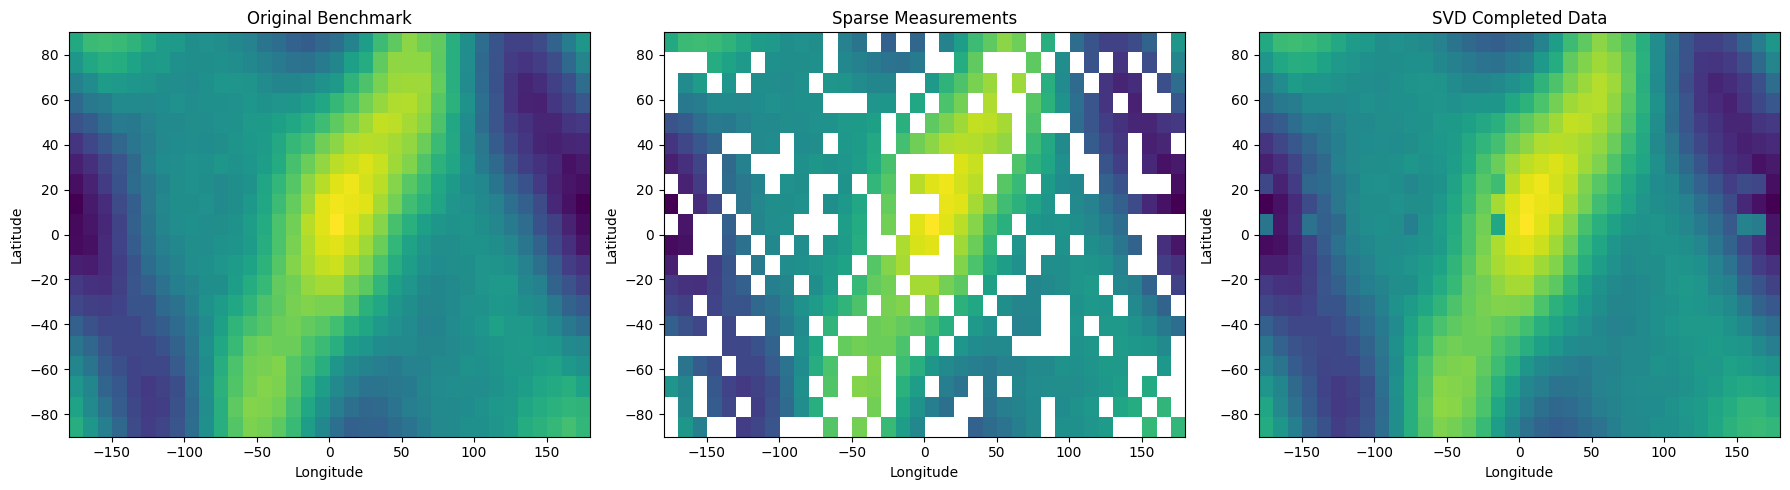

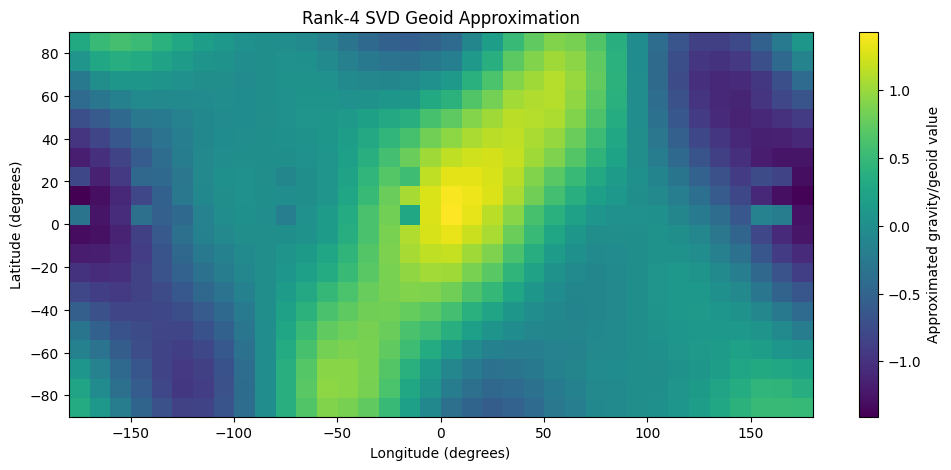

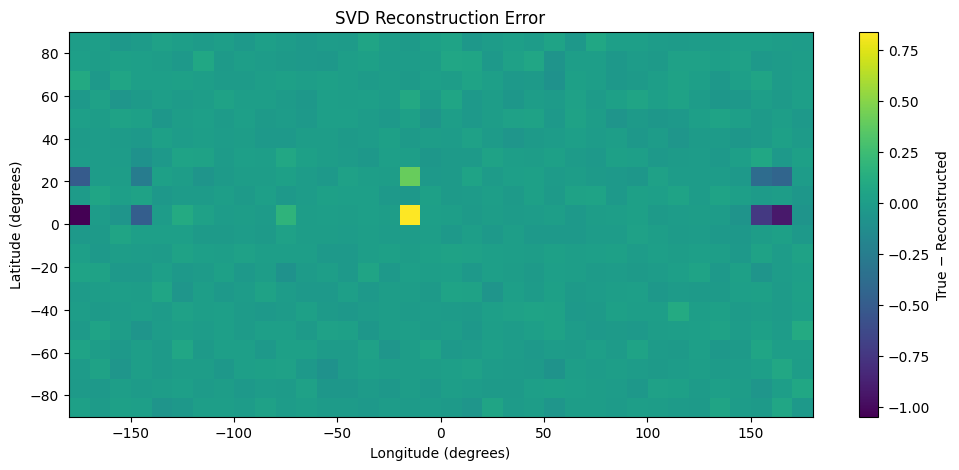

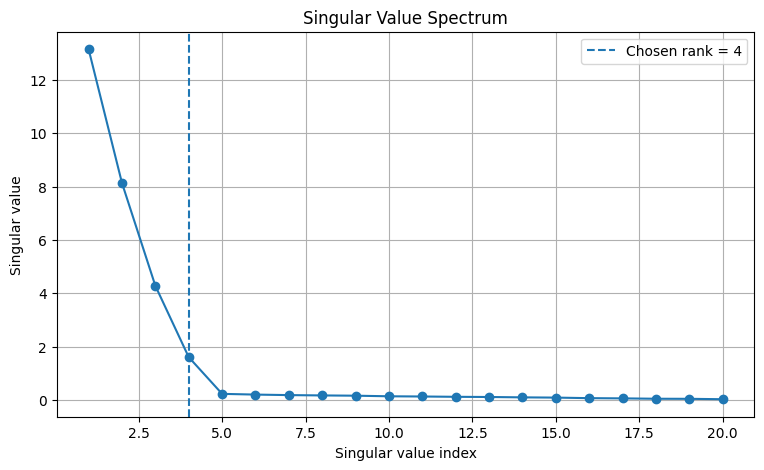

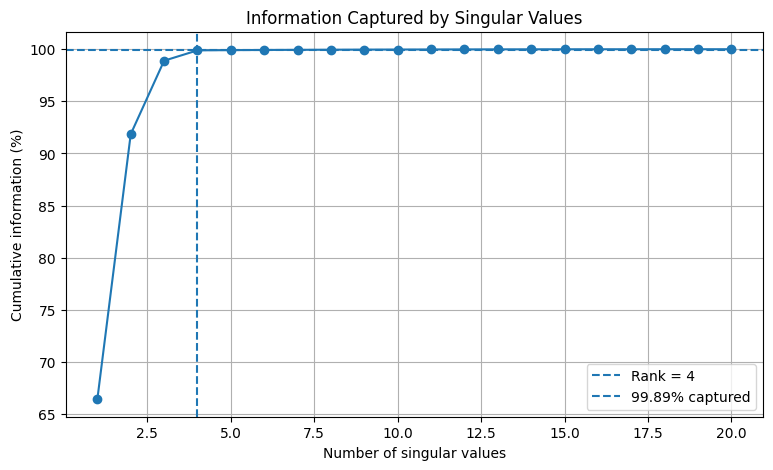

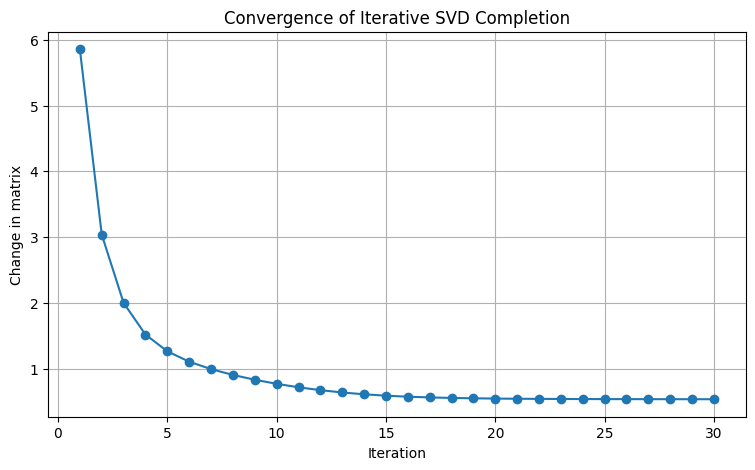



                 RANK COMPARISON
Rank | Information Captured | RMSE
-----------------------------------------------------------------
   1 |                66.43% | 0.34694
   2 |                91.85% | 0.16893
   3 |                98.90% | 0.05545
   4 |                99.89% | 0.08201
   5 |                99.91% | 0.08151
   8 |                99.95% | 0.08058
  10 |                99.97% | 0.08020


              SMALL SVD VERIFICATION

Original matrix A:
[[3. 2.]
 [2. 3.]]

Singular values:
[5. 1.]

U:
[[-0.707 -0.707]
 [-0.707  0.707]]

Vᵀ:
[[-0.707 -0.707]
 [-0.707  0.707]]

UΣVᵀ:
[[3. 2.]
 [2. 3.]]

Reconstruction error: 9.930136612989092e-16


                  FINAL PROJECT RESULT

1. The gravity/geoid-like observations were arranged as
   a 20 × 36 matrix.

2. 30.42% of the measurements were
   intentionally removed to simulate sparse observations.

3. SVD decomposed the matrix as:

       A = U Σ Vᵀ

4. The largest 4 singular values were retained.

5. The low-rank model

In [ ]:
8
# ============================================================
# GEIOD APPROXIMATION FROM SATELLITE DATA (E5)
# B.Tech Mathematics Mini Project
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

np.set_printoptions(precision=3, suppress=True)

# ============================================================
# 1. USER CONFIGURATION
# ============================================================

N_LAT = 20                 # Number of latitude points
N_LON = 36                 # Number of longitude points
RANK = 4                   # Number of singular values retained
MISSING_RATE = 0.30        # 30% measurements are missing
N_ITERATIONS = 30          # SVD completion iterations
NOISE_LEVEL = 0.03         # Small measurement noise
RANDOM_SEED = 42           # For reproducibility

np.random.seed(RANDOM_SEED)

print("=" * 65)
print("       GEIOD APPROXIMATION FROM SATELLITE DATA (E5)")
print("=" * 65)

print("\nPROJECT CONFIGURATION")
print("-" * 65)
print("Latitude points :", N_LAT)
print("Longitude points:", N_LON)
print("SVD Rank        :", RANK)
print("Missing rate    :", MISSING_RATE * 100, "%")
print("Iterations      :", N_ITERATIONS)


# ============================================================
# 2. CREATE LATITUDE-LONGITUDE GRID
# ============================================================

latitudes = np.linspace(-90, 90, N_LAT)
longitudes = np.linspace(-180, 180, N_LON, endpoint=False)

LAT, LON = np.meshgrid(
    latitudes,
    longitudes,
    indexing="ij"
)

lat = np.radians(LAT)
lon = np.radians(LON)

print("\nGRID")
print("-" * 65)
print("Matrix shape:", LAT.shape)


# ============================================================
# 3. CREATE BENCHMARK GRAVITY/GEOID-LIKE DATA
# ============================================================
#
# IMPORTANT:
# This is a synthetic benchmark dataset.
# It is NOT actual satellite gravity data.
#
# We create a smooth global spatial field so that the
# low-rank property of the data can be demonstrated.
#
# ============================================================

pattern_1 = (
    1.00 *
    np.cos(lat) *
    np.cos(lon)
)

pattern_2 = (
    0.60 *
    np.sin(lat) *
    np.sin(2 * lon)
)

pattern_3 = (
    0.35 *
    np.cos(2 * lat) *
    np.cos(3 * lon)
)

pattern_4 = (
    0.20 *
    np.sin(2 * lat) *
    np.cos(lon)
)

true_data = (
    pattern_1 +
    pattern_2 +
    pattern_3 +
    pattern_4
)

# Add small measurement noise
noise = NOISE_LEVEL * np.random.randn(
    N_LAT,
    N_LON
)

true_data = true_data + noise

print("\nBENCHMARK DATA")
print("-" * 65)
print("Minimum:", round(true_data.min(), 4))
print("Maximum:", round(true_data.max(), 4))
print("Mean   :", round(true_data.mean(), 4))


# ============================================================
# 4. DISPLAY ORIGINAL DATA
# ============================================================

plt.figure(figsize=(12, 5))

plt.imshow(
    true_data,
    extent=[-180, 180, -90, 90],
    origin="lower",
    aspect="auto"
)

plt.colorbar(
    label="Gravity / geoid-like value"
)

plt.xlabel("Longitude (degrees)")
plt.ylabel("Latitude (degrees)")
plt.title("Complete Benchmark Gravity/Geoid-like Dataset")

plt.show()


# ============================================================
# 5. CREATE SPARSE OBSERVATIONS
# ============================================================

# True  = measurement available
# False = measurement missing

observed_mask = (
    np.random.rand(N_LAT, N_LON)
    > MISSING_RATE
)

sparse_data = np.full_like(
    true_data,
    np.nan
)

sparse_data[observed_mask] = (
    true_data[observed_mask]
)

observed_percentage = (
    100 * observed_mask.mean()
)

missing_percentage = (
    100 * (~observed_mask).mean()
)

print("\nSPARSE DATA")
print("-" * 65)
print(
    "Observed measurements:",
    np.sum(observed_mask)
)

print(
    "Missing measurements :",
    np.sum(~observed_mask)
)

print(
    "Observed percentage   :",
    round(observed_percentage, 2),
    "%"
)

print(
    "Missing percentage    :",
    round(missing_percentage, 2),
    "%"
)


# ============================================================
# 6. DISPLAY SPARSE DATA
# ============================================================

plt.figure(figsize=(12, 5))

plt.imshow(
    sparse_data,
    extent=[-180, 180, -90, 90],
    origin="lower",
    aspect="auto"
)

plt.colorbar(
    label="Observed value"
)

plt.xlabel("Longitude (degrees)")
plt.ylabel("Latitude (degrees)")
plt.title("Sparse Gravity Measurements")

plt.show()


# ============================================================
# 7. BASIC SVD
# ============================================================

"""
Mathematical model:

             A = U Σ Vᵀ

where:

A = original data matrix
U = left singular vectors
Σ = singular-value matrix
Vᵀ = transpose of right singular vectors

Low-rank approximation:

             A_k = U_k Σ_k V_kᵀ
"""

# NumPy SVD cannot directly process NaN values,
# so missing values are temporarily replaced with zero.

initial_matrix = np.nan_to_num(
    sparse_data,
    nan=0.0
)

U, S, VT = np.linalg.svd(
    initial_matrix,
    full_matrices=False
)

print("\nSVD RESULTS")
print("-" * 65)

print("Original matrix shape:", initial_matrix.shape)
print("U shape              :", U.shape)
print("Sigma shape          :", S.shape)
print("Vᵀ shape             :", VT.shape)

print("\nFirst 10 singular values:")
print(S[:10])


# ============================================================
# 8. SINGULAR VALUE ENERGY
# ============================================================

energy = S ** 2

cumulative_energy = (
    np.cumsum(energy) /
    np.sum(energy)
) * 100

print("\nSINGULAR VALUE ENERGY")
print("-" * 65)
print("Rank | Information Captured")

for k in range(
    1,
    min(10, len(S)) + 1
):

    print(
        f"{k:4d} | "
        f"{cumulative_energy[k-1]:8.2f}%"
    )


# ============================================================
# 9. LOW-RANK SVD FUNCTION
# ============================================================

def low_rank_svd(A, rank):

    """
    Calculates:

        A_k = U_k Σ_k V_kᵀ

    using only the largest 'rank'
    singular values.
    """

    U, S, VT = np.linalg.svd(
        A,
        full_matrices=False
    )

    U_k = U[:, :rank]

    S_k = S[:rank]

    VT_k = VT[:rank, :]

    A_k = (
        U_k @
        np.diag(S_k) @
        VT_k
    )

    return (
        A_k,
        U_k,
        S_k,
        VT_k
    )


# ============================================================
# 10. INITIAL LOW-RANK APPROXIMATION
# ============================================================

initial_approximation, _, _, _ = (
    low_rank_svd(
        initial_matrix,
        RANK
    )
)

print("\nLOW-RANK APPROXIMATION")
print("-" * 65)
print(
    f"Rank-{RANK} approximation calculated."
)


# ============================================================
# 11. ITERATIVE SVD DATA COMPLETION
# ============================================================

def svd_matrix_completion(
    sparse_matrix,
    observed_mask,
    rank=4,
    iterations=30
):

    """
    Iterative SVD matrix completion.

    Step 1:
        Replace missing values with the mean.

    Step 2:
        Perform SVD.

    Step 3:
        Keep only the largest 'rank' singular values.

    Step 4:
        Reconstruct the low-rank matrix.

    Step 5:
        Keep the original observed measurements
        unchanged.

    Step 6:
        Use reconstructed values for missing locations.

    Repeat the process.
    """

    observed_values = (
        sparse_matrix[observed_mask]
    )

    initial_mean = np.mean(
        observed_values
    )

    # Initial estimate
    completed = np.where(
        observed_mask,
        sparse_matrix,
        initial_mean
    )

    errors = []

    for iteration in range(iterations):

        # ------------------------------
        # Step 1: SVD
        # ------------------------------

        U, S, VT = np.linalg.svd(
            completed,
            full_matrices=False
        )

        # ------------------------------
        # Step 2: Keep largest
        # singular values
        # ------------------------------

        U_k = U[:, :rank]

        S_k = S[:rank]

        VT_k = VT[:rank, :]

        # ------------------------------
        # Step 3: Reconstruct
        # ------------------------------

        low_rank = (
            U_k @
            np.diag(S_k) @
            VT_k
        )

        # ------------------------------
        # Step 4: Calculate change
        # ------------------------------

        change = np.linalg.norm(
            completed - low_rank
        )

        errors.append(change)

        # ------------------------------
        # Step 5: Preserve observed data
        # ------------------------------

        completed = np.where(
            observed_mask,
            sparse_matrix,
            low_rank
        )

    return completed, errors


# ============================================================
# 12. PERFORM DATA COMPLETION
# ============================================================

completed_data, completion_errors = (
    svd_matrix_completion(
        sparse_data,
        observed_mask,
        rank=RANK,
        iterations=N_ITERATIONS
    )
)

print("\nDATA COMPLETION")
print("-" * 65)
print("Iterative SVD completion finished.")


# ============================================================
# 13. FINAL LOW-RANK GEOID MODEL
# ============================================================

final_model, U_k, S_k, VT_k = (
    low_rank_svd(
        completed_data,
        RANK
    )
)

print("\nFINAL LOW-RANK MODEL")
print("-" * 65)

print("Selected rank:", RANK)

print(
    "Retained singular values:"
)

print(S_k)

print("\nMatrix dimensions:")

print("U_k  :", U_k.shape)

print(
    "Sigma:",
    (len(S_k), len(S_k))
)

print(
    "V_kᵀ :",
    VT_k.shape
)


# ============================================================
# 14. FINAL INFORMATION CAPTURED
# ============================================================

_, final_S, _ = np.linalg.svd(
    completed_data,
    full_matrices=False
)

final_energy = final_S ** 2

captured_energy = (
    np.sum(
        final_energy[:RANK]
    )
    /
    np.sum(final_energy)
) * 100

print("\nINFORMATION CAPTURED")
print("-" * 65)

print(
    f"Rank-{RANK} model captures "
    f"{captured_energy:.2f}% "
    f"of the matrix energy."
)


# ============================================================
# 15. ACCURACY CALCULATION
# ============================================================

# Since this is a benchmark dataset,
# the original true values are known.

overall_rmse = np.sqrt(
    np.mean(
        (true_data - final_model) ** 2
    )
)

missing_mask = ~observed_mask

missing_rmse = np.sqrt(
    np.mean(
        (
            true_data[missing_mask]
            -
            final_model[missing_mask]
        ) ** 2
    )
)

observed_rmse = np.sqrt(
    np.mean(
        (
            true_data[observed_mask]
            -
            final_model[observed_mask]
        ) ** 2
    )
)

print("\nRECONSTRUCTION ACCURACY")
print("-" * 65)

print(
    f"Overall RMSE  : {overall_rmse:.5f}"
)

print(
    f"Missing RMSE  : {missing_rmse:.5f}"
)

print(
    f"Observed RMSE : {observed_rmse:.5f}"
)


# ============================================================
# 16. ORIGINAL vs SPARSE vs COMPLETED
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

# Original
axes[0].imshow(
    true_data,
    extent=[-180, 180, -90, 90],
    origin="lower",
    aspect="auto"
)

axes[0].set_title(
    "Original Benchmark"
)

axes[0].set_xlabel(
    "Longitude"
)

axes[0].set_ylabel(
    "Latitude"
)


# Sparse
axes[1].imshow(
    sparse_data,
    extent=[-180, 180, -90, 90],
    origin="lower",
    aspect="auto"
)

axes[1].set_title(
    "Sparse Measurements"
)

axes[1].set_xlabel(
    "Longitude"
)

axes[1].set_ylabel(
    "Latitude"
)


# Completed
axes[2].imshow(
    completed_data,
    extent=[-180, 180, -90, 90],
    origin="lower",
    aspect="auto"
)

axes[2].set_title(
    "SVD Completed Data"
)

axes[2].set_xlabel(
    "Longitude"
)

axes[2].set_ylabel(
    "Latitude"
)

plt.tight_layout()

plt.show()


# ============================================================
# 17. FINAL GEOID APPROXIMATION
# ============================================================

plt.figure(figsize=(12, 5))

plt.imshow(
    final_model,
    extent=[-180, 180, -90, 90],
    origin="lower",
    aspect="auto"
)

plt.colorbar(
    label="Approximated gravity/geoid value"
)

plt.xlabel(
    "Longitude (degrees)"
)

plt.ylabel(
    "Latitude (degrees)"
)

plt.title(
    f"Rank-{RANK} SVD Geoid Approximation"
)

plt.show()


# ============================================================
# 18. RECONSTRUCTION ERROR MAP
# ============================================================

error_map = (
    true_data -
    final_model
)

plt.figure(figsize=(12, 5))

plt.imshow(
    error_map,
    extent=[-180, 180, -90, 90],
    origin="lower",
    aspect="auto"
)

plt.colorbar(
    label="True − Reconstructed"
)

plt.xlabel(
    "Longitude (degrees)"
)

plt.ylabel(
    "Latitude (degrees)"
)

plt.title(
    "SVD Reconstruction Error"
)

plt.show()


# ============================================================
# 19. SINGULAR VALUE SPECTRUM
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(final_S) + 1),
    final_S,
    marker="o"
)

plt.axvline(
    RANK,
    linestyle="--",
    label=f"Chosen rank = {RANK}"
)

plt.xlabel(
    "Singular value index"
)

plt.ylabel(
    "Singular value"
)

plt.title(
    "Singular Value Spectrum"
)

plt.grid(True)

plt.legend()

plt.show()


# ============================================================
# 20. CUMULATIVE INFORMATION CHART
# ============================================================

cumulative_final_energy = (
    np.cumsum(final_S ** 2)
    /
    np.sum(final_S ** 2)
) * 100

plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(final_S) + 1),
    cumulative_final_energy,
    marker="o"
)

plt.axvline(
    RANK,
    linestyle="--",
    label=f"Rank = {RANK}"
)

plt.axhline(
    cumulative_final_energy[RANK - 1],
    linestyle="--",
    label=(
        f"{cumulative_final_energy[RANK - 1]:.2f}% captured"
    )
)

plt.xlabel(
    "Number of singular values"
)

plt.ylabel(
    "Cumulative information (%)"
)

plt.title(
    "Information Captured by Singular Values"
)

plt.grid(True)

plt.legend()

plt.show()


# ============================================================
# 21. SVD COMPLETION CONVERGENCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    range(1, N_ITERATIONS + 1),
    completion_errors,
    marker="o"
)

plt.xlabel(
    "Iteration"
)

plt.ylabel(
    "Change in matrix"
)

plt.title(
    "Convergence of Iterative SVD Completion"
)

plt.grid(True)

plt.show()


# ============================================================
# 22. RANK COMPARISON
# ============================================================

print("\n")
print("=" * 65)
print("                 RANK COMPARISON")
print("=" * 65)

print(
    "Rank | Information Captured | RMSE"
)

print("-" * 65)

for rank in [1, 2, 3, 4, 5, 8, 10]:

    if rank <= len(final_S):

        model, _, _, _ = (
            low_rank_svd(
                completed_data,
                rank
            )
        )

        rmse = np.sqrt(
            np.mean(
                (true_data - model) ** 2
            )
        )

        energy_percent = (
            np.sum(
                final_S[:rank] ** 2
            )
            /
            np.sum(final_S ** 2)
        ) * 100

        print(
            f"{rank:4d} | "
            f"{energy_percent:20.2f}% | "
            f"{rmse:.5f}"
        )


# ============================================================
# 23. SMALL SVD MATHEMATICAL VERIFICATION
# ============================================================

A = sp.Matrix([
    [3, 2],
    [2, 3]
])

A_numpy = np.array(
    A
).astype(float)

U_test, S_test, VT_test = (
    np.linalg.svd(
        A_numpy
    )
)

Sigma_test = np.diag(
    S_test
)

reconstructed_A = (
    U_test @
    Sigma_test @
    VT_test
)

print("\n")
print("=" * 65)
print("              SMALL SVD VERIFICATION")
print("=" * 65)

print("\nOriginal matrix A:")
print(A_numpy)

print("\nSingular values:")
print(S_test)

print("\nU:")
print(U_test)

print("\nVᵀ:")
print(VT_test)

print("\nUΣVᵀ:")
print(reconstructed_A)

print(
    "\nReconstruction error:",
    np.linalg.norm(
        A_numpy -
        reconstructed_A
    )
)


# ============================================================
# 24. FINAL PROJECT RESULT
# ============================================================

print("\n")
print("=" * 65)
print("                  FINAL PROJECT RESULT")
print("=" * 65)

print(
    f"""
1. The gravity/geoid-like observations were arranged as
   a {N_LAT} × {N_LON} matrix.

2. {missing_percentage:.2f}% of the measurements were
   intentionally removed to simulate sparse observations.

3. SVD decomposed the matrix as:

       A = U Σ Vᵀ

4. The largest {RANK} singular values were retained.

5. The low-rank model was calculated using:

       A_k = U_k Σ_k V_kᵀ

6. Missing observations were estimated using iterative
   SVD matrix completion.

7. The rank-{RANK} model captures approximately
   {captured_energy:.2f}% of the matrix energy.

8. Overall reconstruction RMSE:
       {overall_rmse:.5f}

9. RMSE on missing values:
       {missing_rmse:.5f}

10. This demonstrates how a small number of singular values
    can represent the dominant large-scale spatial pattern.

REAL-WORLD APPLICATIONS
-----------------------
• GPS and geoid height correction
• Satellite navigation
• Gravity-field modelling
• Geophysics
• Earth observation

IMPORTANT:
This experiment uses a synthetic benchmark gravity/geoid-like
field. A real geoid model would require actual satellite
gravity/geopotential observations and a physical geodetic model.
"""
)

print("=" * 65)
print("                 PROJECT COMPLETE")
print("=" * 65)